# DMRG Test: Block Growth Version

Welcome to the

## Debauch of Indices ##

>"The utility of the absolute differential calculus of Ricci and Levi-Civita must be tempered by an avoidance of excessively formal calculations, where the debauch of indices disguises an often very simple geometric reality. It is this reality that I have sought to reveal."

From the preface of the book *Geometry of Riemannian spaces* by Élie Cartan in 1928.

<Br>

This is a notebook for a simple traditional DMRG algorithm with block growth method. The code shown in this notebook is adapted from Dr. Garrison and Dr. Mishmash from the [simple-dmrg website](https://simple-dmrg.readthedocs.io/en/latest/). This notebook is prepared by Mr. [Song Menghan](https://quantummc.xyz/members/menghan-song/), Mr. [Min Long](https://quantummc.xyz/members/min-long/), Mr. [Shibo Shan](https://quantummc.xyz/members/shibo-shan/) and [ZYM](https://quantummc.xyz/members/ziyang-meng/).

For further information, one can read the reference articles of this notebook by Malvezzi [arXiv:cond-mat/0304375](https://arxiv.org/abs/cond-mat/0304375v1) and by Schollwoeck [arXiv:1008.3477](https://arxiv.org/abs/1008.3477v2).

## 1. Introduction

### 1.1 Background
The core idea behind the DMRG is to find a way in which one can increase the system size without increasing the Hilbert space.

This is typically done in two steps:

$\bullet $ Construct large systems from samll systems by gradually increase the system size. So far, the Hilbert space grows exponentially and we have not improved anything.

$\bullet $ Truncate the Hilbert space to a certain value, keeping its size invariant when more sites are added.

Here two key steps one needs to implement:

$\bullet$ How to enlarge the system?

$\bullet$ What is the criterion to truncate the Hilbert space?


### 1.2 Procedure
To start with, we consider a single site which is described by the state $d_i (i=1,...,D)$. Define a block $B(l,m)$ consists of $l$ sites and $H_B$ denotes the Hamiltonion of length $l$ chain. For a Heisenberg chain, $H_B$ is,
$$
H_B = \sum_{\left \langle i,j \right \rangle \in B }\hat{S_i}\hat{S_j},
$$
where $B$ is a block containing $l$ sites and $m$ is the dimension of the basis in which we represent the operators of the block (without any truncation, $m=D^{L}$).

The block is then grown by adding a site to it, forming an enlarged block, $B^{e}$. Denote $\left | b_1  \right \rangle ...\left | b_m  \right \rangle $ and $\left | d_1  \right \rangle ...\left | d_D  \right \rangle $ the basis of the block and the additional site, the basis of the enlarged block is their direct product,

$$
\left | b_k^{e}  \right \rangle=\left | b_i  \right \rangle \otimes \left | d_j  \right \rangle,
$$
where $k = 1,2,...,D^{l+1}$, $i = 1,2,...,D^{l}$, $j = 1,...,D$

and thus the dimension of the Hilbert space for $B^{e}$ is the product of that for $B(l,m)$ and a site, $i.e. m\times D = D^{l}\times D = D^{l+1}$.

<img src="https://raw.githubusercontent.com/hylu666/hku-physics4150/main/DMRG_tutorial/block_enlarge.png" width=500 height=400/>


The next step is to form the superblock which consists of two enlarged blocks connected to each other. This sample code considers the open boundary conditions (OBC) and aims to compute the ground state energy of an infinite chain.

For infinite chain algorithm, the superblock is formed by connecting the enlarged block $B_{e}$ and its replica(reflected) $B_{e}^{'}$ together. Compute the Hamiltonian of the superblock and diagonalize it to find its ground state energy and wavefunction,

$$
\left | \Psi_{gs} \right \rangle =\sum_{i=1}^{m\times D}\sum_{j=1}^{m\times D} a_{i,j}\left | b_{i}^{e} \right \rangle\otimes \left | b_j^{'e} \right \rangle,
$$

which is written in a basis that is the tensor product of the system(e.g. left enlarged block) and the environment(e.g. right replica). We can further compute the density matrix of the system,

$$
\rho _{i,i^{'}}=\sum_{j=1}^{m\times D}a_{i,j}a_{i^{'},j}^{*} .
$$

**In statistic mechanics, density matrix tells us which states of the system contribute the most to the above ground state.** The density matrix has the same dimension and block-diagonal structure of $H_e$, for the enlarged block. Let's denote $\left | u_{a} \right \rangle, w_{a}(a=1,...,m\times D)$ the eigenvectors and eigenvalues of $\rho$, then $\sum_{a}w_a =1$ with $w_a$ is the probability of the system being in the state $\left | u_{a} \right \rangle$ in the space spanned by the ground state $\left | \Psi_{gs} \right \rangle$.

<br/>

### 1.3 Reduced density matrix
The above analysis guides to keep only the most relevant states to describe the system at the ground states, which reduce the exponentially large Hilbert space into a fixed size. To make an optimal choice, we need to order the state $\left | u_{a} \right \rangle$ by their eigenvalues $w_{a}$ in a decending order and we only use the largest $m$ eigenvectors as a new reduced basis to describe $B_e$. Now the enlarged block is interpreted as $B_e (l+1,m)$ instead of $B_e (l+1,m\times D)$.

Since we adapt a new basis for $B_e$. We need to rotate the operators into the new basis. For example, the Hamiltonian is transformed as,

$$
H_{B(l+1,m)}=OH_{e}O^{\dagger},
$$

where the rows of the $(m,(m\times D))$ matrix $O$ are the selected  $\left | u_{a} \right \rangle$. Again, we clearly see that the Hilbert space size is cut back to $m$.

<img src="https://raw.githubusercontent.com/hylu666/hku-physics4150/main/DMRG_tutorial/truncation.png" width=570 height=250/>

Then we continue add a site to the exsisting block and repeat the routine. We are able to reach a large system size since the Hilbert space size has a ceiling $m$. By monitoring whether the ground state energy of the superblock converges, one can successfully approximate the true ground state and few low-lying states of the system at infinitely large sizes a.k.a. the thermodynamic limit.


## 2. Sample code

In [3]:
from __future__ import print_function, division
import numpy as np
from scipy.sparse import kron, identity
from scipy.sparse.linalg import eigsh  # Lanczos routine from ARPACK
from collections import namedtuple
import matplotlib.pyplot as plt

In [4]:
Block = namedtuple("Block", ["length", "basis_size", "operator_dict"])
EnlargedBlock = namedtuple("EnlargedBlock", ["length", "basis_size", "operator_dict"])

model_d = 2 # single site basis for spin-1/2


In [5]:
def is_valid_block(block):
    for op in block.operator_dict.values():
        if op.shape[0] != block.basis_size or op.shape[1] != block.basis_size:
            return False
    return True
is_valid_enlarged_block = is_valid_block

$ J_+ |j,m\rangle =\sqrt{j(j+1)-m(m+1)}|j,m+1\rangle$

$ J_{-} |j,m\rangle = \sqrt{j(j+1)-m(m-1)}|j,m-1\rangle$

In [6]:
def GetSpinOp(spin):
    '''
    Given a spin quantum number
    return various spin operators and one site H
    '''
    Jp = lambda j,m: np.sqrt(j*(j+1)-m*(m+1))
    Jm = lambda j,m: np.sqrt(j*(j+1)-m*(m-1))

    Mdim = int(2*spin+1)

    Sz = np.zeros((Mdim,Mdim))
    Sp = np.zeros((Mdim,Mdim))
    Sm = np.zeros((Mdim,Mdim))

    for ii in range(Mdim):
        sm = spin-ii
        Sz[ii,ii]= sm
        if ii > 0:
            Sp[ii-1,ii]=Jp(spin,sm)
        if ii < 2*spin:
            Sm[ii+1,ii]=Jm(spin,sm)
    Sx = (Sp+Sm)/2
    Sy = (Sp-Sm)/(2j)

    H1 = np.zeros((Mdim,Mdim))

    return Sz,Sp,Sm,H1

In [7]:
Sz1,Sp1,Sm1,H1 = GetSpinOp(1/2)
Sz1,Sp1,Sm1,H1

(array([[ 0.5,  0. ],
        [ 0. , -0.5]]),
 array([[0., 1.],
        [0., 0.]]),
 array([[0., 0.],
        [1., 0.]]),
 array([[0., 0.],
        [0., 0.]]))

Adding a site to the block, compute the enlarged H as follows:
$$
H_e=H_B\otimes I_d+\frac{J}{2}(S_b^{+}\otimes S_d^{-}+S_b^{-}\otimes S_d^{+})+J_z S_b^{z}\otimes S_d^{z},
$$

considering the internal block part and the interaction part with a new spin.

In [8]:
def H2(Sz1, Sp1, Sz2, Sp2):  # two-site part of the enlarged H
    """
    Given the operators S^z and S^+ on two sites in different Hilbert spaces
    (e.g. two blocks), returns a Kronecker product representing the
    corresponding two-site term in the Hamiltonian that joins the two sites.
    """
    J = Jz = 1.
    TwoSiteH = (J/2)*(kron(Sp1,Sp2.conjugate().transpose())+kron(Sp1.conjugate().transpose(),Sp2))\
    +Jz*kron(Sz1, Sz2)

    return TwoSiteH


In [9]:
initial_block = Block(length=1, basis_size=model_d, operator_dict={
    "H": H1,
    "conn_Sz": Sz1,
    "conn_Sp": Sp1,})

# conn refers to the connection operator, that is, the operator on the edge of
# the block, on the interior of the chain.  We need to be able to represent S^z
# and S^+ on that site in the current basis in order to grow the chain.

In [10]:
initial_block

Block(length=1, basis_size=2, operator_dict={'H': array([[0., 0.],
       [0., 0.]]), 'conn_Sz': array([[ 0.5,  0. ],
       [ 0. , -0.5]]), 'conn_Sp': array([[0., 1.],
       [0., 0.]])})

Together with the Block Hamiltonian $H_b$, we need to present the spin operators of the rightmost site of the $\mathbf{enlarged}$ block in the basis of the enlarged block (basis with one more site added). For example, the spin-1/2 $S_z$ transforms as:
$$
(S_r^{z})_e = I_b\otimes S_d^{z}=I_b\otimes \begin{bmatrix}
 \frac{1}{2} & 0 \\
 0 & -\frac{1}{2}
\end{bmatrix},
$$
where $I_b$ is the identity matrix of the block Hilbert space, $S_d^{z}$ is the $S_z$ operator for the righmost site.

In [11]:
def enlarge_block(block):
    """
    Enlarges the block by adding one site
    Return the Enlarged block
    """
    mblock = block.basis_size
    o = block.operator_dict

    # Create the new operators for the enlarged block.  Our basis becomes a
    # Kronecker product of the Block basis and the single-site basis.  NOTE:
    # `kron` uses the tensor product convention making blocks of the second
    # array scaled by the first.  As such, we adopt this convention for
    # Kronecker products throughout the code.
    enlarged_operator_dict = {
        "H": kron(o["H"], identity(model_d)) + kron(identity(mblock), H1) + H2(o["conn_Sz"], o["conn_Sp"], Sz1, Sp1),
        "conn_Sz": kron(identity(mblock), Sz1),
        "conn_Sp": kron(identity(mblock), Sp1),
    }

    return EnlargedBlock(length=(block.length + 1),
                         basis_size=(block.basis_size * model_d),
                         operator_dict=enlarged_operator_dict)

In [12]:
def ChangeBasis(operator,trans_mat):
    '''
    Transform the operator into the truncated basis with trans_mat
    '''
    op_new = trans_mat.conjugate().transpose().dot(operator.dot(trans_mat))
    return op_new


Here we define a single DMRG step with one site added.

Note that the formation of the superblock Hamiltonian is similar to that for $H_e$. They both consist three parts: Hamiltonian for both enlarged block (in the construction for $H_e$, one can regard the additional site as a right block with a single site Hamiltonion which is zero) and the interaction between the connecting sites.

$$
H_s=H_e\otimes I_e^{'}+I_e \otimes H_e^{'}+\frac{J}{2}\{(S_r^{+})_e \otimes (S_r^{-})_{e}^{'}+(S_r^{-})_e\otimes (S_r^{+})_e^{'}\}+J_z (S_r^{z})_e\otimes (S_r^{z})_e^{'},
$$

where the subscript $r$ means the rightmost site of the block, and $'$ stands for the replica enlarged block.

We sum up the eigenvalues of the discarded eigenstates $(1-\sum_{a=1}^{m}w_a)$ as the measure for the truncation error. In many cases, this number is roughly proportional to the error in the energy.

In [33]:
def single_dmrg_step(sys,env,mm):
    '''
    single DMRG step with the maximum truncation mm, mm states in the new basis
    '''
    assert is_valid_block(sys)
    assert is_valid_block(env) #check whether the block is legal

    sys_enl = enlarge_block(sys)

    if sys is env: #if they are same, not need to compute again
        env_enl = sys_enl
    else:
        env_enl = enlarge_block(env)

    assert is_valid_enlarged_block(sys_enl)
    assert is_valid_enlarged_block(env_enl) #check whether enl_block is legal

    #construct the superblock Hamiltonian.
    m_sys_enl = sys_enl.basis_size
    m_env_enl = env_enl.basis_size
    sys_enl_op = sys_enl.operator_dict
    env_enl_op = env_enl.operator_dict
    superblock_H = kron(sys_enl_op["H"],identity(m_env_enl))\
                  +kron(identity(m_sys_enl), env_enl_op["H"])\
                  +H2(sys_enl_op["conn_Sz"], sys_enl_op["conn_Sp"], env_enl_op["conn_Sz"], env_enl_op["conn_Sp"])

    #find the superblock ground state.
    #'SA' means find the 'smallest in amplitude' eig_value
    #|psi0> = sigma{i}sigma{j}: a(i,j)|bi>|bj>
    #|bi>, |bj> are the basis of the sys and env
    #rehape the eigenvector such that (row,colum) corresponds to (sys,env)
    #Now, the matrix elements of psi0 are a(i,j)
    #rho is the density matrix
    (energy), psi0 = eigsh(superblock_H, k=5, which="SA")
    psi0 = psi0[:,0].reshape([sys_enl.basis_size, -1], order="C") #gs wavefunction
    rho = np.dot(psi0,psi0.conjugate().transpose()) # trace_env


    evals,evecs = np.linalg.eigh(rho)
    possible_eigenstates = []
    for eig_val, eig_vec in zip(evals, evecs.transpose()):
        possible_eigenstates.append((eig_val, eig_vec))
    possible_eigenstates.sort(reverse=True, key=lambda x: x[0])  # largest eigenvalue first
    print("\nSorted Eigenvalues of density matrix:")
    for eig_val, _ in possible_eigenstates:
        print(eig_val)

    #Based on the truncation 'mm', compute trans_mat
    my_m = min(len(possible_eigenstates),mm)
    trans_mat = np.zeros((sys_enl.basis_size, my_m), dtype='d', order='F')
    for index in range(my_m):
        eigenvalue, eigenvector = possible_eigenstates[index]
        trans_mat[:, index] = eigenvector


    truncation_error = 1 - sum([x[0] for x in possible_eigenstates[:my_m]])
    print("truncation error:", truncation_error)
    #change the basis for each operator
    new_operator_dict={}
    for name, op in sys_enl.operator_dict.items():
        new_operator_dict[name] = ChangeBasis(op,trans_mat)

    newblock = Block(length=sys_enl.length,
                     basis_size=my_m,
                     operator_dict=new_operator_dict)
    return newblock, energy[0],(energy[1]-energy[0]),(energy[4]-energy[0])





In [34]:
(energy,), psi0  = eigsh(Sz1, k=1, which="SA")

In [35]:
energy,psi0

(np.float64(-0.5),
 array([[ 0.],
        [-1.]]))

### 2.1 Infinite system algorithm

In [36]:
def infinite_system(L,mm):
    block = initial_block
    #keep growing the block
    #let the right block = left block, i.e. env=sys
    while 2*block.length<L:
        #1st step, grow 1 to 2 sites, hence 4 sites in superblock
        print('L =',block.length*2 + 2)
        block, energy,gap,gap4 = single_dmrg_step(block, block, mm)
        #print('E/L =', energy/(block.length*2))
        #print('gap=',gap)
        #print("gap4=",gap4)


In [37]:
def Run_infinite(L):

    if __name__ == "__main__":
        np.set_printoptions(precision=10, suppress=True, threshold=10000, linewidth=300)
        infinite_system(L, mm=32)



In [38]:
L_list=[]
gap_half_list=[]

L=64
mm=32
block = initial_block
#keep growing the block
#let the right block = left block, i.e. env=sys
while 2*block.length<L:
    #1st step, grow 1 to 2 sites, hence 4 sites in superblock
    print('L =',block.length*2 + 2)
    L_list.append(block.length*2 + 2)
    block, energy,gap,gap4 = single_dmrg_step(block, block, mm)
    #print('E/L =', energy/(block.length*2))
    #print('gap=',gap)
    #print("gap4=",gap4)
    gap_half_list.append(gap)

L = 4

Sorted Eigenvalues:
0.9330127018922185
0.022329099369260242
0.022329099369260214
0.0223290993692602
truncation error: 8.881784197001252e-16
L = 6

Sorted Eigenvalues:
0.49879106413702967
0.4987910641370281
0.0010336998513355714
0.001033699851335546
8.761800581794042e-05
8.761800581792415e-05
8.761800581791725e-05
8.761800581786847e-05
truncation error: -4.440892098500626e-16
L = 8

Sorted Eigenvalues:
0.893388710701316
0.035519007495860996
0.035519007495860636
0.03551900749586057
1.6468623735284768e-05
1.646862373527367e-05
1.6468623735252824e-05
4.139281000261409e-06
1.9036600384792388e-07
1.9036600384404444e-07
1.9036600384285383e-07
3.011217683081055e-08
3.0112176829300506e-08
3.0112176828775564e-08
3.011217682840216e-08
3.011217682659486e-08
truncation error: -2.220446049250313e-16
L = 10

Sorted Eigenvalues:
0.49657898819906954
0.4965789881990673
0.0028686345913975404
0.002868634591397501
0.00027594044155856837
0.00027594044155855753
0.0002759404415585427
0.0002759404415584

In [32]:
L_rev = 1/np.array(L_list)
L_rev

array([0.25      , 0.16666667, 0.125     , 0.1       , 0.08333333,
       0.07142857, 0.0625    , 0.05555556, 0.05      , 0.04545455,
       0.04166667, 0.03846154, 0.03571429, 0.03333333, 0.03125   ,
       0.02941176, 0.02777778, 0.02631579, 0.025     , 0.02380952,
       0.02272727, 0.02173913, 0.02083333, 0.02      , 0.01923077,
       0.01851852, 0.01785714, 0.01724138, 0.01666667, 0.01612903,
       0.015625  ])

### 2.2 Finite system algorithm

In this fintie system algorithm, we aims to simulate the finite chain with length L precisely instead of reaching the thermal dynamic limit. Therefore, we need to grow the block to our required length, fix it and we do sweeps to equilibrate the chain. The overall procedure is listed below:
1. First use the infinite size algorithm until the superblock size reaches the chain size L under investigation. After every truncation save all operators of the reduced block to disk.
2. Denote the length of the system block by $l$. Load the environment block of size $L − l − 2$ from disk, this is the right block.
3. Call single_dmrg_step with inputs sys and env which are save in the disk. Then, the system block's length increases by one, $l\to l+1$.
4. Continue step 2 and 3 untill the environment block becomes a single site.
5. Then reverse the system and the environment, do step 4 untill energy converges.


In [ ]:
def graphic(sys_block, env_block, sys_label="l"):
    """This is a graphic representation of the block,
    =: stands for the system
    -: stands for the environment
    **: stands for the intermedium two sites
    """
    assert sys_label in ("l", "r")
    graphic = ("=" * sys_block.length) + "**" + ("-" * env_block.length)
    if sys_label == "r":
        # The system should be on the right and the environment should be on
        # the left, so reverse the graphic.
        graphic = graphic[::-1]
    return graphic

In [ ]:
def finite_system_algorithm(L, m_warmup, m_sweep_list):
    '''
    This function print the process of sweeps and return the ground state energy of the finite system.
    A sweep goes as:
    ====**---- >> ======**-- >> -------**= >> --**====== >> =**------- >> ====**----

    L: system length
    m_warmup: the truncation length used for growing the system to length L
    m_sweep_list: a list contains different 'mm' for consideration.
    '''
    assert L % 2 == 0  # require that L is an even number

    # To keep things simple, this dictionary is not actually saved to disk, but
    # we use it to represent persistent storage.
    block_disk = {}  # "disk" storage for Block objects

    # Use the infinite system algorithm to build up to desired size.  Each time
    # we construct a block, we save it for future reference as both a left
    # ("l") and right ("r") block, as the infinite system algorithm assumes the
    # environment is a mirror image of the system.
    block = initial_block
    block_disk["l", block.length] = block
    block_disk["r", block.length] = block
    while 2 * block.length < L:
        # Perform a single DMRG step and save the new Block to "disk"
        # grow block size to L/2 and now the system is L/2 -2
        print(graphic(block, block))
        block, energy,gap,gap4 = single_dmrg_step(block, block, mm=m_warmup)
        print("E/L =", energy / (block.length * 2))
        #print("gap =",gap)
        #print("gap4 =",gap4)

        block_disk["l", block.length] = block
        block_disk["r", block.length] = block

    # Now that the system is built up to its full size, we perform sweeps using
    # the finite system algorithm.  At first the left block will act as the
    # system, growing at the expense of the right block (the environment), but
    # once we come to the end of the chain these roles will be reversed.
    sys_label, env_label = "l", "r"
    sys_block = block; del block  # rename the variable
    for mm in m_sweep_list:
        while True:
            # Load the appropriate environment block from "disk"
            env_block = block_disk[env_label, L - sys_block.length - 2]
            if env_block.length == 1:
                # We've come to the end of the chain, so we reverse course.
                sys_block, env_block = env_block, sys_block
                sys_label, env_label = env_label, sys_label

            # Perform a single DMRG step.
            print(graphic(sys_block, env_block, sys_label))
            sys_block,energy,gap,gap4 = single_dmrg_step(sys_block, env_block, mm=mm)

            print("E/L =", energy / L)
            #print("gap =",gap)
            #print("gap4 =",gap4)

            # Save the block from this step to disk.
            block_disk[sys_label, sys_block.length] = sys_block

            # Check whether we just completed a full sweep.
            if sys_label == "l" and 2 * sys_block.length == L:
                break  # escape from the "while True" loop

In [ ]:
def Run_finite(L):
    if __name__ == "__main__":
        np.set_printoptions(precision=10, suppress=True, threshold=10000, linewidth=300)

        finite_system_algorithm(L, m_warmup=10, m_sweep_list=[10])

In [ ]:
Run_finite(48)

=**-
truncation error: 1.1102230246251565e-16
E/L = -0.4040063509461096
==**--
truncation error: 1.2212453270876722e-15
E/L = -0.41559618898132045
===**---
truncation error: 3.4092688883102795e-07
E/L = -0.4218665748359869
====**----
truncation error: 1.406779471802011e-07
E/L = -0.4258028861459492
=====**-----
truncation error: 2.160821670704749e-06
E/L = -0.42850647290057103
======**------
truncation error: 9.705370959123272e-07
E/L = -0.43047729477681257
=======**-------
truncation error: 5.544365736964707e-06
E/L = -0.43197938169634875
========**--------
truncation error: 2.5329997176415375e-06
E/L = -0.4331599018637754
=========**---------
truncation error: 9.905744671079297e-06
E/L = -0.4341145241689647
==========**----------
truncation error: 4.502897850255927e-06
E/L = -0.434899321596702
===========**-----------
truncation error: 1.4637892047697498e-05
E/L = -0.43555902240304767
============**------------
truncation error: 6.579463378009187e-06
E/L = -0.4361176755794468
=======

## 3. Benchmark with ED

In [ ]:
def ED_1d(N,OBC=None):
    dimension=2**N
    #spin chain with all spin-down
    z='0'*N
    # initialize hamiltonian
    H=np.zeros((dimension,dimension))
    # Matrix Construction
    for a in range(dimension):
        if OBC==True:
            num=N-1
        else:
            num=N
        for i in range(num): #N-1 if OBC

            j=np.mod(i+1,N)
            state_chain=bin(a)[2:] # the first two should be omitted for this 'bin' function
            l=len(state_chain)
    #        print(state_chain)
            state_chain=z[0:N-l]+state_chain # make the length equal to N
            if state_chain[i]==state_chain[j]: # i=j only diagonal elements
                H[a,a]+=0.25
            else:                              # else, the raising/lowering operators also have contributions
                H[a,a]-=0.25
                # then exchange i,j
                element_i=state_chain[i]
                element_j=state_chain[j]
                #flip
                if max(i,j)==N-1:
                    if i>j:  #here we are doing the concatenation of string (you can try other methods)
                        state_chain=element_i+state_chain[1:N-1]+element_j
    #                    print(state_chain)
                    else:
                        state_chain=state_chain[0:i]+element_j+element_i
    #                    print(state_chain)
                else:
                    state_chain=state_chain[0:i]+element_j+element_i+state_chain[j+1:]
    #            print(state_chain)
                b=int(state_chain,2)
                H[a,b]+=0.5
    eig_value=np.real(np.linalg.eig(H)[0])# eigen_values
    eig_vec=np.real(np.linalg.eig(H)[1])  # eigenstates

    idx_sorted1 = np.argsort(eig_value)
    eig_value=eig_value[idx_sorted1]
    eig_vec=eig_vec[:,idx_sorted1]
    eig_value[0]/N, eig_vec[:,0]
    energy_level=np.sort(eig_value/N)
    #return Ground Energy per site
    return energy_level[0],(energy_level[1]-energy_level[0])*N


In [ ]:
for L in [4,6,8,10]:
    print('L =',L)
    E0,gap = ED_1d(L,OBC=False)
    print('E/L =', E0)
    print("gap =", gap)

L = 4
E/L = -0.49999999999999967
gap = 0.9999999999999984
L = 6
E/L = -0.46712927295533174
gap = 0.6847416489820877
L = 8
E/L = -0.4563866761171472
gap = 0.5226743450925904
L = 10
E/L = -0.45154463544920587
gap = 0.42323900775335765


## 4. Test for spin-1 chain

In [ ]:
Block = namedtuple("Block", ["length", "basis_size", "operator_dict"])
EnlargedBlock = namedtuple("EnlargedBlock", ["length", "basis_size", "operator_dict"])

model_d = 3 # single site basis for spin-1/2

Sz1,Sp1,Sm1,H1 = GetSpinOp(1)
Sz1,Sp1,Sm1,H1


(array([[ 1.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0., -1.]]),
 array([[0.          , 1.4142135624, 0.          ],
        [0.          , 0.          , 1.4142135624],
        [0.          , 0.          , 0.          ]]),
 array([[0.          , 0.          , 0.          ],
        [1.4142135624, 0.          , 0.          ],
        [0.          , 1.4142135624, 0.          ]]),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]))

In [ ]:
initial_block = Block(length=1, basis_size=model_d, operator_dict={
    "H": H1,
    "conn_Sz": Sz1,
    "conn_Sp": Sp1,})

In [ ]:
Run_finite(10)

=**-
truncation error: 2.7755575615628914e-15
E/L = -1.1614378277661448
==**--
truncation error: 0.0009637667328707966
E/L = -1.228379161570767
===**---
truncation error: 0.00023749592490018845
E/L = -1.2638406498160637
====**----
truncation error: 0.002186642695549579
E/L = -1.2873897496280768
=====**---
truncation error: 0.00042821121289926545
E/L = -1.286679718540088
======**--
truncation error: 0.0016114160995007731
E/L = -1.2872624397050536
-------**=
truncation error: -2.220446049250313e-16
E/L = -1.2865824750497914
------**==
truncation error: 0.001611416099500551
E/L = -1.2872624397050547
-----**===
truncation error: 0.00043497597698727297
E/L = -1.286758897021525
----**====
truncation error: 0.002138198095375854
E/L = -1.2874653719691007
---**=====
truncation error: 0.00042980534656456015
E/L = -1.286856990876323
--**======
truncation error: 0.001425155117512622
E/L = -1.287422187526637
=**-------
truncation error: -1.1102230246251565e-15
E/L = -1.2868751014890631
==**------
t

In [ ]:
L_list=[]
gap_one_list=[]

L=64
mm=32
block = initial_block
#keep growing the block
#let the right block = left block, i.e. env=sys
while 2*block.length<L:
    #1st step, grow 1 to 2 sites, hence 4 sites in superblock
    print('L =',block.length*2 + 2)
    L_list.append(block.length*2 + 2)
    block, energy,gap,gap4 = single_dmrg_step(block, block, mm)
    #print('E/L =', energy/(block.length*2))
    #print('gap=',gap)
    #print("gap4=",gap4)
    gap_one_list.append(gap4)

L = 4
truncation error: -1.5543122344752192e-15
L = 6
truncation error: 1.9984014443252818e-15
L = 8
truncation error: 1.3120555630852238e-07
L = 10
truncation error: 2.808953417643423e-07
L = 12
truncation error: 9.752941624308065e-07
L = 14
truncation error: 1.7008644951355123e-06
L = 16
truncation error: 2.793269583967195e-06
L = 18
truncation error: 3.914347883160474e-06
L = 20
truncation error: 5.011936151655405e-06
L = 22
truncation error: 6.100133650321915e-06
L = 24
truncation error: 6.907904410602406e-06
L = 26
truncation error: 7.763258302984077e-06
L = 28
truncation error: 8.299277404422156e-06
L = 30
truncation error: 8.933416749346001e-06
L = 32
truncation error: 9.276907239064158e-06
L = 34
truncation error: 9.69482700918789e-06
L = 36
truncation error: 9.870199073502839e-06
L = 38
truncation error: 1.0156981035347457e-05
L = 40
truncation error: 1.0203661817254073e-05
L = 42
truncation error: 1.0410598497712087e-05
L = 44
truncation error: 1.0370780770041499e-05
L = 46
t

In [ ]:
from scipy.optimize import curve_fit

<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-726674191.py:31: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel("$\Delta$",fontsize=15)
/tmp/ipython-input-726674191.py:53: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel("$\Delta$",fontsize=15)


Text(0, 0.5, '$\\Delta$')

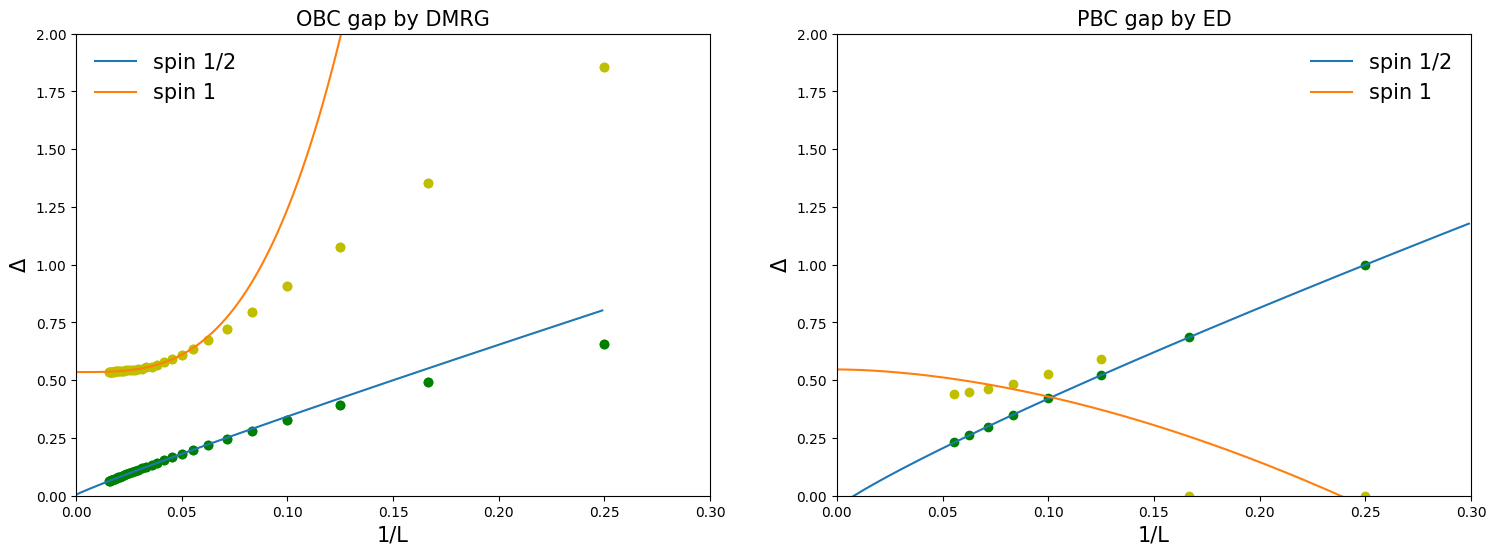

In [ ]:
fig=plt.figure(figsize=(18,6))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)


ax1.scatter(L_rev,gap_half_list,color="g")
ax1.scatter(L_rev,gap_one_list,color="y")


def func(x,a,b,c):
    return a*x**b+c

ax1.scatter(L_rev,gap_half_list,color="g")
ax1.scatter(L_rev,gap_one_list,color="y")

popt1,pcov1 = curve_fit(func,L_rev[10:],gap_half_list[10:])
x1 = np.arange(0,0.25,0.001)
y1 = [func(i,popt1[0],popt1[1],popt1[2]) for i in x1]
ax1.plot(x1,y1,label = "spin 1/2")

popt2,pcov2 = curve_fit(func,L_rev[10:],gap_one_list[10:])
x2 = np.arange(0,0.25,0.001)
y2 = [func(i,popt2[0],popt2[1],popt2[2]) for i in x2]
ax1.plot(x2,y2,label="spin 1")

ax1.set_xlim(0,0.3)
ax1.set_ylim(0,2)
ax1.legend(frameon=False,prop={"size":15})
ax1.set_title('OBC gap by DMRG',fontsize=15)
ax1.set_xlabel('1/L',fontsize=15)
ax1.set_ylabel("$\Delta$",fontsize=15)

xx1,yy1 = np.sort(1/np.arange(4,19,2)),np.array([0.232,0.261,0.298,0.348,0.423,0.523,0.685,1])
yy2 = np.array([0.44,0.45,0.46,0.4841964699122272,0.5248,0.5935,0,0])
ax2.scatter(xx1,yy1,color="g")
ax2.scatter(xx1,yy2,color="y")

popt3,pcov3 = curve_fit(func,xx1,yy1)
xxx1 = np.arange(0,0.3,0.001)
yyy1 = [func(i,popt3[0],popt3[1],popt3[2]) for i in xxx1]
ax2.plot(xxx1,yyy1,label="spin 1/2")

popt4,pcov4 = curve_fit(func,xx1,yy2)
xxx2 = np.arange(0,0.3,0.001)
yyy2 = [func(i,popt4[0],popt4[1],popt4[2]) for i in xxx2]
ax2.plot(xxx2,yyy2,label="spin 1")
ax2.set_xlim(0,0.3)
ax2.set_ylim(0,2)

ax2.legend(frameon=False,prop={"size":15})
ax2.set_title('PBC gap by ED',fontsize=15)
ax2.set_xlabel('1/L',fontsize=15)
ax2.set_ylabel("$\Delta$",fontsize=15)

##txt="From Prof.Han-Qing Wu of SYSU"
##fig.text(0.8,0.005,txt,ha="right",fontsize=12)

As we can see, DMRG easily approch to large system sizes which are intractable for ED. The difference of the low lying gap between spin-1/2 and spin-1 can be clearly seen.

However, the $\Delta$ at L $\to$ ∞ obtained from our DMRG code is different from that of ED. This is due to the fact that we truncate the Hilbert space using the ground state density matrix and thus we discard some information of excited states. One can eliminate this issue by truncating the Hilbert space using not only the ground state density matrix but also those of first few excited states.